# Import libraries

In [1]:
import pandas as pd
import numpy as np

import os
from pathlib import Path

import pickle

from src.scenario_v0 import SimulationScenario as SimulationScenarioV0
from src.scenario import SimulationScenario
from src.simulator_casadi import create_simulator
from src.policy import PDController
from src.system import HydraulicSystem

In [2]:
# Define the initial state
p_atm = 1e5
# initial_state = np.array([1e3, 0, 0, p_atm, p_atm])
initial_state = np.array([1e3, 0, 0, p_atm, p_atm])

system = HydraulicSystem(
    init_state=initial_state,
    system_parameters_init = {
        "p_l_gauge": 1.5e5,
        "x_th_limits": (0., 20.),
        "freq_th": 500.0,
        "m_p": 20e-3,
        "D_th": 200e-6, # WAS 200e-6, then 5e-3
        "D_hydr": 20e-3,
        "D_work": 20e-3,
        "h_work_init": 1e3,
        "D_exit": 0.33e-3,
        "l_exit": 8.5e-3,
        "p_coulomb": 10e3, # WAS 10e3, then 1e3
        "eta": 0.70,
        "zeta_th": 5.0, # WAS 5.0, then 0.1
        "rho_hydr": 1e3,
        "rho_work": 1e3,
        "beta_v_hydr": 0.49e-9,
        "beta_v_work": 0.49e-9,
        "sigma_work": 73e-3,
        "mu_work": 1.0e-3,
        "v_j": 200.,
        "jet_length_std": 5e-2, # Was 5e-2
        "jet_velocity_std": 1e-2, # Was 1e-2
        "pressure_std": 0.,
        "p_atm": 1e5, # Atmosphere (ambient) pressure, Pa
        "g": 9.81, # gravity constant, m/s^2
    },
)

simulator = create_simulator(
    simulator_type='casadi',
    system=system,
    N_steps=10,
    state_init=initial_state,
    integration_method='rk4',  # Change from 'collocation' to 'rk4'
    n_substeps=10000,
    use_symbolic=True
)

# Is not used in this notebook
controller = PDController(
    P_coef=20,
    D_coef=0,
)

new_scenario = SimulationScenario(
    simulator=simulator,
    policy=controller,
    root_data_path=None,
    seed=None
)

scenario = SimulationScenarioV0(
    None,
    None,
    None
)

In [3]:

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  # Reset to default to avoid regelum overrides

import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import seaborn as sns
sns.set_theme()  # Reset seaborn to default theme to avoid previous settings
sns.set_style('darkgrid')
%matplotlib inline

# Load P-control datasets

In [4]:
# GET PATHS
root_path_P = './data/P_controller'
prefix = '2024-03-27_122643'

all_seeds_P = list(range(1, 6))
all_seeds_P = list(map(str, all_seeds_P))
print(all_seeds_P)

pathes_P = {}

for path in Path(root_path_P).iterdir():
    seed = str(path).split('_seed_')[-1]
    if seed in all_seeds_P and prefix in str(path):
        pathes_P[seed] = path
display(pathes_P)

# LOAD IN ONE DATASET
total_costs_P = []

for seed in pathes_P:
    seed_obs_df = pd.read_csv(
        pathes_P[seed] / "clean_observations.csv", 
        index_col=0,
    )
    seed_obs_df.rename({'0': seed}, axis=1, inplace=True)
    seed_act_df = pd.read_csv(
        pathes_P[seed] / "actions.csv", 
        index_col=0,
    )
    seed_act_df.rename({'0': seed}, axis=1, inplace=True)
    
    seed_total_cost = scenario.compute_total_objective(
        seed_obs_df.values, 
        actions=seed_act_df.values,
    )
    total_costs_P.append(seed_total_cost)

total_costs_P = np.array(total_costs_P)
central_P = total_costs_P.mean()
stds = total_costs_P.std()
bottom_P = central_P - stds
top_P = central_P + stds

print(f'bottom_P = {bottom_P:.3f}')
print(f'central_P = {central_P:.3f}')
print(f'top_P = {top_P:.3f}')

['1', '2', '3', '4', '5']


{
    '3': PosixPath('data/P_controller/2024-03-27_122643_seed_3'),
    '4': PosixPath('data/P_controller/2024-03-27_122643_seed_4'),
    '5': PosixPath('data/P_controller/2024-03-27_122643_seed_5'),
    '2': PosixPath('data/P_controller/2024-03-27_122643_seed_2'),
    '1': PosixPath('data/P_controller/2024-03-27_122643_seed_1')
}

bottom_P = 2.203
central_P = 2.463
top_P = 2.722


# Load old RL-datasets

In [5]:
# GET PATHS
root_path = './data'
prefix_list = [
    '2024-03-26_103818',
    '2024-03-26_103819',
    '2024-03-26_221635',
]

all_seeds = list(range(1, 15))
all_seeds = list(map(str, all_seeds))
print(all_seeds)

pathes = {}

for path in Path(root_path).iterdir():
    seed = str(path).split('seed_')[-1]
    if seed in all_seeds and any(prefix in str(path) for prefix in prefix_list):
        pathes[seed] = path
display(pathes)


# LOAD IN ONE DATASET
learning_curves = []

for seed in pathes:
    seed_df = pd.read_csv(
        pathes[seed] / "learning curve.csv", 
        index_col=0,
    )
    seed_df.rename({'0': seed}, axis=1, inplace=True)
    learning_curves.append(seed_df)
    
learning_curves = pd.concat(learning_curves, axis=1)
learning_curves = learning_curves[all_seeds] # Sort columns
learning_curves.describe()

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']


{
    '8': PosixPath('data/2024-03-26_221635_seed_8'),
    '12': PosixPath('data/2024-03-26_221635_seed_12'),
    '7': PosixPath('data/2024-03-26_103819_seed_7'),
    '2': PosixPath('data/2024-03-26_103818_seed_2'),
    '9': PosixPath('data/2024-03-26_221635_seed_9'),
    '3': PosixPath('data/2024-03-26_103818_seed_3'),
    '6': PosixPath('data/2024-03-26_103819_seed_6'),
    '14': PosixPath('data/2024-03-26_221635_seed_14'),
    '13': PosixPath('data/2024-03-26_221635_seed_13'),
    '4': PosixPath('data/2024-03-26_103819_seed_4'),
    '11': PosixPath('data/2024-03-26_221635_seed_11'),
    '1': PosixPath('data/2024-03-26_103818_seed_1'),
    '10': PosixPath('data/2024-03-26_221635_seed_10'),
    '5': PosixPath('data/2024-03-26_103819_seed_5')
}

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3.509594,2.539125,3.242997,2.590975,2.992448,3.366597,2.526493,3.239561,3.144272,2.591885,2.977496,2.737044,2.633010,2.508933
std,2.815633,0.597689,1.464547,0.534131,0.839903,0.089173,0.517598,0.405167,0.591629,0.685547,1.274854,0.879833,0.676643,0.509862
min,2.029746,1.978085,1.947065,1.971402,1.944724,3.277720,1.981067,1.950224,1.932075,2.010353,2.081743,1.946155,1.996836,2.004178
25%,2.675513,2.061144,2.061144,2.151025,2.507207,3.318071,2.097617,3.292637,3.034240,2.115975,2.437394,2.071874,2.068741,2.061144
50%,3.046134,2.182604,2.770871,2.333226,2.826242,3.335576,2.270462,3.319910,3.310186,2.287483,2.539668,2.580328,2.169326,2.255822
75%,3.340841,3.155271,3.415613,3.171213,3.121285,3.364743,2.999093,3.357394,3.402858,2.890734,3.174850,3.037851,3.297914,2.886899
max,21.468832,4.741112,7.785267,3.769596,6.068163,3.722469,3.973656,5.476902,5.646765,5.416898,15.800960,8.236204,4.327940,3.996705


Let us drop "not-working" seeds

,2,4,7,11,14
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2.539125,2.590975,2.526493,2.977496,2.508933
std,0.597689,0.534131,0.517598,1.274854,0.509862
min,1.978085,1.971402,1.981067,2.081743,2.004178
25%,2.061144,2.151025,2.097617,2.437394,2.061144
50%,2.182604,2.333226,2.270462,2.539668,2.255822
75%,3.155271,3.171213,2.999093,3.174850,2.886899
max,4.741112,3.769596,3.973656,15.800960,3.996705


Number of learning curves: 5


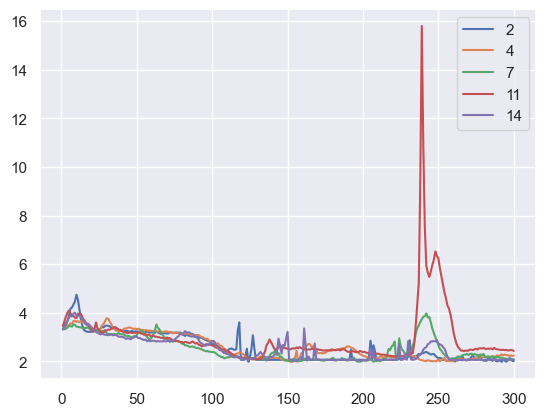

In [6]:
# seeds_to_drop = ['1', '3', '5', '6', '8', '9', '12']
# seeds_to_drop = ['1', '3', '5', '6', '9', '12', '13']
seeds_to_drop = ['1', '3', '5', '6', '8', '9', '10', '12', '13']
learning_curves_selected = learning_curves.drop(seeds_to_drop, axis=1)
display(learning_curves_selected.describe())
learning_curves_selected.plot()
print(f'Number of learning curves: {learning_curves_selected.shape[1]}')

means


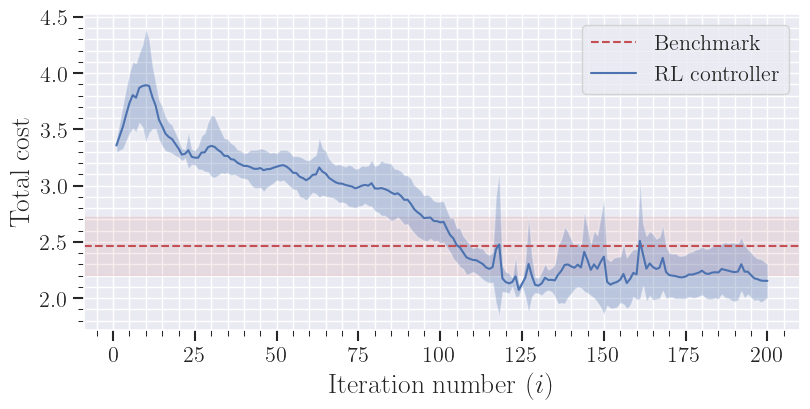

In [7]:
# sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "xtick.bottom" : True, 
    "ytick.left" : True,
    'xtick.major.size': 8,
    'xtick.major.width': 1.5,
    'xtick.minor.size': 4,
    'xtick.minor.width': 0.75,
    'ytick.major.size': 8,
    'ytick.major.width': 1.5,
    'ytick.minor.size': 4,
    'ytick.minor.width': 0.75,
})


def plot_total_cost(df, plot_type='means', savefig=False):
    if plot_type == 'means':
        central = df.mean(axis=1)
        stds = df.std(axis=1)
        bottom = central - stds
        top = central + stds
    elif plot_type == 'medians':
        central = df.median(axis=1)
        bottom = df.quantile(0.25, axis=1)
        top = df.quantile(0.75, axis=1)
    print(plot_type)
    
    fig, ax = plt.subplots(1, 1, figsize=(8,4))
    ax.set_ylabel("Total cost", fontsize=20)
    ax.set_xlabel("Iteration number $(i)$", fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.xaxis.grid(True, which='minor')
    ax.yaxis.grid(True, which='minor')
    
    plt.axhline(central_P, linestyle='--', color='r', label='Benchmark')
    plt.axhspan(bottom_P, top_P, alpha=0.1, color='r')
    
    central.plot(label='RL controller')
    plt.fill_between(central.index, bottom, top, alpha=0.3)
    
    plt.legend(fontsize=16)
    
    plt.tight_layout(pad=0.2)
    if savefig:
        plt.savefig("learning_curve_3_state.pdf", dpi=400)
    plt.show();

plot_total_cost(learning_curves_selected.iloc[:200], savefig=True)

In [8]:
learning_curves_selected.mean(axis=1).iloc[123]

2.0732179720806982

# Plot actions and observations

In [9]:
# GET PATHS
root_path = './data'
prefix_list = [
    '2024-03-26_103818',
    '2024-03-26_103819',
    '2024-03-26_221635',
]

all_seeds = list(range(1, 15))
all_seeds = list(map(str, all_seeds))
print(all_seeds)

pathes = {}

for path in Path(root_path).iterdir():
    seed = str(path).split('seed_')[-1]
    if seed in all_seeds and any(prefix in str(path) for prefix in prefix_list):
        pathes[seed] = path
display(pathes)

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']


{
    '8': PosixPath('data/2024-03-26_221635_seed_8'),
    '12': PosixPath('data/2024-03-26_221635_seed_12'),
    '7': PosixPath('data/2024-03-26_103819_seed_7'),
    '2': PosixPath('data/2024-03-26_103818_seed_2'),
    '9': PosixPath('data/2024-03-26_221635_seed_9'),
    '3': PosixPath('data/2024-03-26_103818_seed_3'),
    '6': PosixPath('data/2024-03-26_103819_seed_6'),
    '14': PosixPath('data/2024-03-26_221635_seed_14'),
    '13': PosixPath('data/2024-03-26_221635_seed_13'),
    '4': PosixPath('data/2024-03-26_103819_seed_4'),
    '11': PosixPath('data/2024-03-26_221635_seed_11'),
    '1': PosixPath('data/2024-03-26_103818_seed_1'),
    '10': PosixPath('data/2024-03-26_221635_seed_10'),
    '5': PosixPath('data/2024-03-26_103819_seed_5')
}

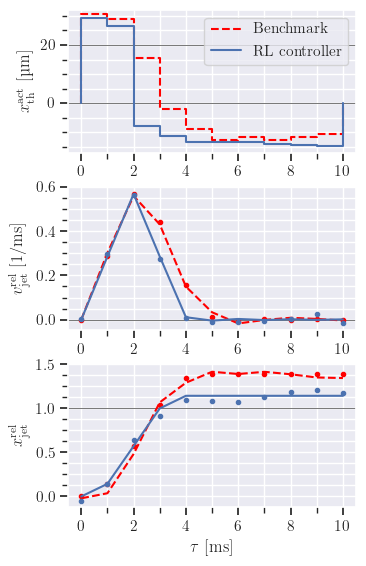

In [10]:
sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
})

seeds_colors = {
    '2': 'b',
    # '4': 'g',
    # '5': 'b',
    # '7': 'c',
    # '14': 'orange',
}

P_seeds_colors = {
    '2': 'r',
}

# def plot_iteration_results()
# LOAD IN ONE DATASET
iteration = 200

seed_observations = {}
seed_clean_observations = {}
seed_actions = {}


P_clean_obs_df = pd.read_csv(
    pathes_P['2'] / "clean_observations.csv", 
    index_col=0,
)

P_obs_df = pd.read_csv(
    pathes_P['2'] / "observations.csv", 
    index_col=0,
)

P_act_df = pd.read_csv(
    pathes_P['2'] / "actions.csv", 
    index_col=0,
)


for seed in seeds_colors:
    with open(pathes[seed] / "iteration_data.pkl", 'rb') as f:
        data = pickle.load(f)
    
    load_iteration = iteration
    if iteration > len(data):
        load_iteration = len(data)
    
    seed_clean_observations[seed] = data[load_iteration - 1]['clean_observations']
    seed_observations[seed] = data[load_iteration - 1]['observations']
    seed_actions[seed] = [0.]
    seed_actions[seed].extend(data[load_iteration - 1]['actions'][:-1])

fig, axes = plt.subplots(3, 1, figsize=(4,6),) # gridspec_kw={'height_ratios': [0.8, 1, 1, 1]})
    
# PLOT ACTIONS
ax = axes[0]

ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)
ax.axhline(20, color='black', linewidth=0.5, alpha=0.75)

P_act_df.plot('step', 'action', color='red', linestyle='--', ax=ax, label='Benchmark')
i = 1
for seed in seeds_colors:
    real_actions = scenario.get_real_actions(seed_actions[seed])
    ax.plot(real_actions[:,0], real_actions[:,1], label='RL controller', color=seeds_colors[seed]) # f'our controller: seed {i}'
    i += 1
    

ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.xaxis.grid(True, which='minor')
ax.yaxis.grid(True, which='minor')

ax.set_ylim(top=32.0, bottom=-17.0)
    
ax.set_ylabel(r"$x^\mathrm{act}_\mathrm{th}$ [µm]")
ax.set_xlabel("")

ax.legend(loc='upper right')

# PLOT JET VELOCITIES
ax = axes[1]

ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)


P_obs_df.iloc[:,1].plot(color='red', linestyle='--', ax=ax)
P_clean_obs_df.iloc[:,1].plot(marker='.', color='red', linestyle='', ax=ax)

for seed in seeds_colors:
    ax.plot(seed_clean_observations[seed][:,1], color=seeds_colors[seed])
    ax.plot(seed_observations[seed][:,1], linestyle='', marker='.', color=seeds_colors[seed])
    
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.xaxis.grid(True, which='minor')
ax.yaxis.grid(True, which='minor')

ax.set_ylim(top=.6)
    
ax.set_ylabel(r"$v^\mathrm{rel}_\mathrm{jet}~[1/\mathrm{ms}]$")
ax.set_xlabel("")
    
    # ax.legend().set_visible(False)

# PLOT JET LENGTHS
ax = axes[2]

ax.axhline(1.0, color='black', linewidth=0.5, alpha=0.75)

P_obs_df.iloc[:,0].plot(color='red', linestyle='--', ax=ax)
P_clean_obs_df.iloc[:,0].plot(marker='.', color='red', linestyle='', ax=ax)

for seed in seeds_colors:
    ax.plot(seed_clean_observations[seed][:,0], label=seed, color=seeds_colors[seed])
    ax.plot(seed_observations[seed][:,0], linestyle='', marker='.', color=seeds_colors[seed])

# for iter, ax in zip(iterations_lt, axes[2,:].flat):
    
#     ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)
    
#     sns.lineplot(df, x='time', y=f'jet_velocity_{iter}', color='purple', ax=ax)
    
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.125))
ax.xaxis.grid(True, which='minor')
ax.yaxis.grid(True, which='minor')

ax.set_ylim(top=1.5)
    
ax.set_ylabel(r"$x^\mathrm{rel}_\mathrm{jet}$")
ax.set_xlabel(r"$\tau$ [ms]")

plt.tight_layout(h_pad=0.1)
plt.savefig("simulation_results_3_state.pdf", dpi=400)

In [11]:
print(f'Achieved relative jet length: {seed_clean_observations[seed][:,0][-1]:.3f}')
print(f'Benchmark relative jet length: {P_clean_obs_df.iloc[-1, 0]:.3f}')

Achieved relative jet length: 1.144
Benchmark relative jet length: 1.389


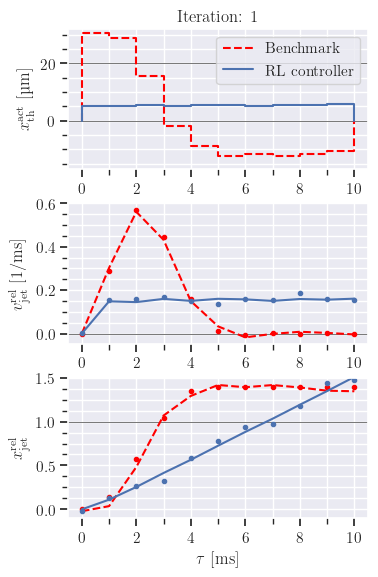

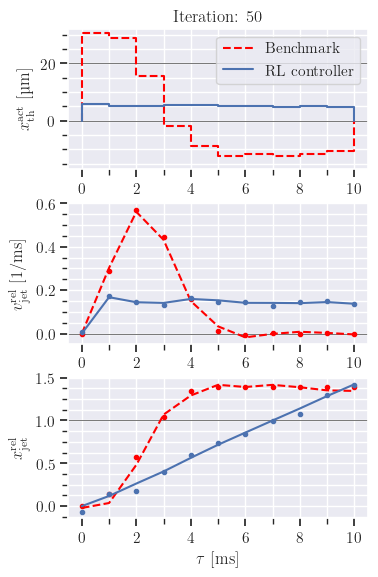

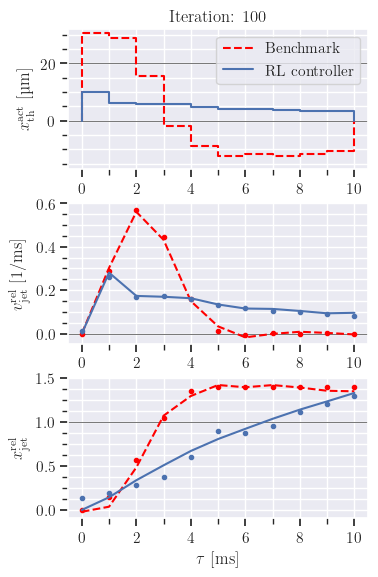

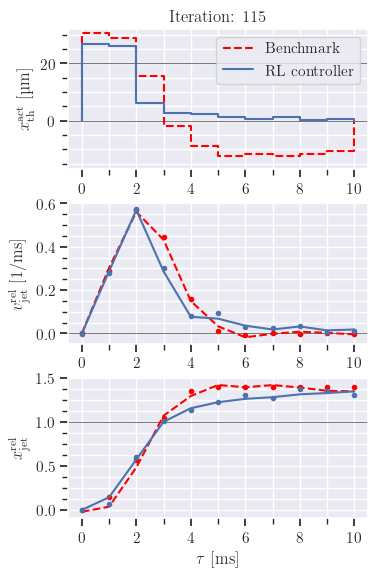

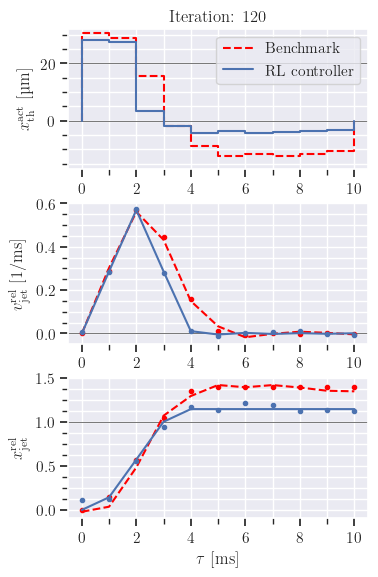

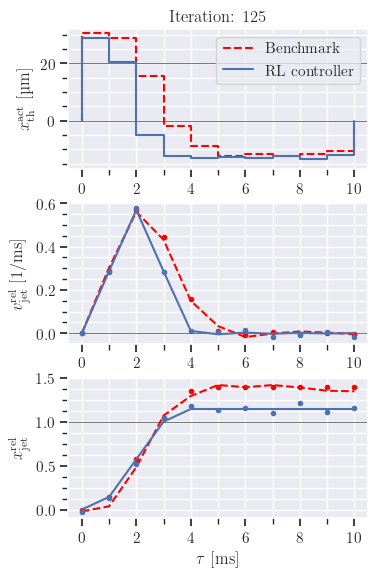

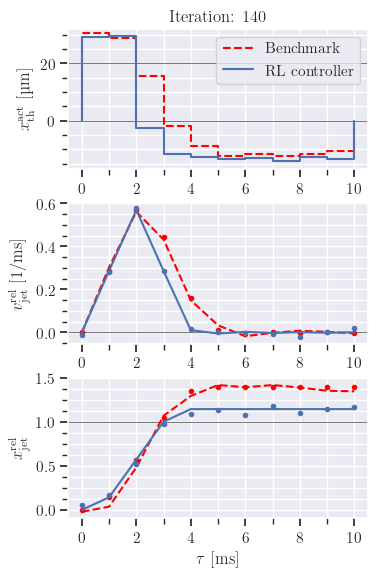

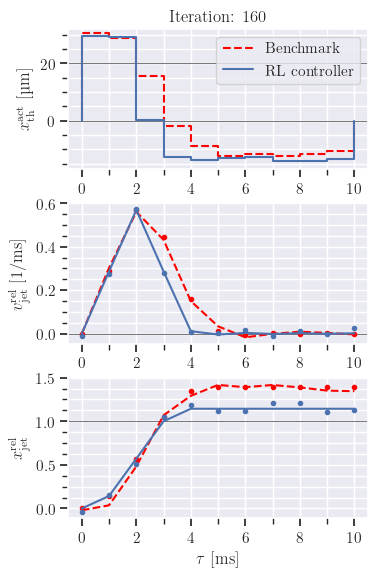

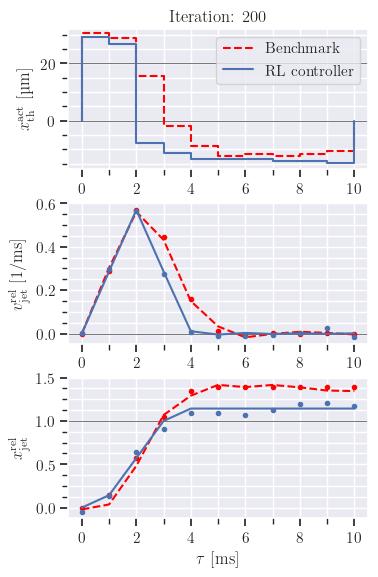

In [12]:
sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
})

seeds_colors = {
    '2': 'b',
    # '4': 'g',
    # '5': 'b',
    # '7': 'c',
    # '14': 'orange',
}

P_seeds_colors = {
    '2': 'r',
}

# def plot_iteration_results()
# LOAD IN ONE DATASET
iteration = 120

for iteration in [1, 50, 100, 115, 120, 125, 140, 160, 200]:

    seed_observations = {}
    seed_clean_observations = {}
    seed_actions = {}


    P_clean_obs_df = pd.read_csv(
        pathes_P[list(P_seeds_colors.keys())[0]] / "clean_observations.csv", 
        index_col=0,
    )

    P_obs_df = pd.read_csv(
        pathes_P[list(P_seeds_colors.keys())[0]] / "observations.csv", 
        index_col=0,
    )

    P_act_df = pd.read_csv(
        pathes_P[list(P_seeds_colors.keys())[0]] / "actions.csv", 
        index_col=0,
    )


    for seed in seeds_colors:
        with open(pathes[seed] / "iteration_data.pkl", 'rb') as f:
            data = pickle.load(f)
        
        load_iteration = iteration
        if iteration > len(data):
            load_iteration = len(data)
        
        seed_clean_observations[seed] = data[load_iteration - 1]['clean_observations']
        seed_observations[seed] = data[load_iteration - 1]['observations']
        seed_actions[seed] = [0.]
        seed_actions[seed].extend(data[load_iteration - 1]['actions'][:-1])

    fig, axes = plt.subplots(3, 1, figsize=(4,6),) # gridspec_kw={'height_ratios': [0.8, 1, 1, 1]})
        
    # PLOT ACTIONS
    ax = axes[0]

    ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)
    ax.axhline(20, color='black', linewidth=0.5, alpha=0.75)

    P_act_df.plot('step', 'action', color='red', linestyle='--', ax=ax, label='Benchmark')
    i = 1
    for seed in seeds_colors:
        real_actions = scenario.get_real_actions(seed_actions[seed])
        ax.plot(real_actions[:,0], real_actions[:,1], label='RL controller', color=seeds_colors[seed]) # f'our controller: seed {i}'
        i += 1
        

    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(5))
    ax.xaxis.grid(True, which='minor')
    ax.yaxis.grid(True, which='minor')
    
    ax.set_ylim(top=32.0, bottom=-17.0)
        
    ax.set_ylabel(r"$x^\mathrm{act}_\mathrm{th}$ [µm]")
    ax.set_xlabel("")

    ax.legend(loc='upper right')
    
    ax.set_title(f'Iteration: {iteration}')

    # PLOT JET VELOCITIES
    ax = axes[1]

    ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)


    P_obs_df.iloc[:,1].plot(color='red', linestyle='--', ax=ax)
    P_clean_obs_df.iloc[:,1].plot(marker='.', color='red', linestyle='', ax=ax)

    for seed in seeds_colors:
        ax.plot(seed_clean_observations[seed][:,1], color=seeds_colors[seed])
        ax.plot(seed_observations[seed][:,1], linestyle='', marker='.', color=seeds_colors[seed])
        
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.xaxis.grid(True, which='minor')
    ax.yaxis.grid(True, which='minor')
    
    ax.set_ylim(top=.6)
        
    ax.set_ylabel(r"$v^\mathrm{rel}_\mathrm{jet}~[1/\mathrm{ms}]$")
    ax.set_xlabel("")
        
        # ax.legend().set_visible(False)

    # PLOT JET LENGTHS
    ax = axes[2]

    ax.axhline(1.0, color='black', linewidth=0.5, alpha=0.75)

    P_obs_df.iloc[:,0].plot(color='red', linestyle='--', ax=ax)
    P_clean_obs_df.iloc[:,0].plot(marker='.', color='red', linestyle='', ax=ax)

    for seed in seeds_colors:
        ax.plot(seed_clean_observations[seed][:,0], label=seed, color=seeds_colors[seed])
        ax.plot(seed_observations[seed][:,0], linestyle='', marker='.', color=seeds_colors[seed])

    # for iter, ax in zip(iterations_lt, axes[2,:].flat):
        
    #     ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)
        
    #     sns.lineplot(df, x='time', y=f'jet_velocity_{iter}', color='purple', ax=ax)
        
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(MultipleLocator(0.125))
    ax.xaxis.grid(True, which='minor')
    ax.yaxis.grid(True, which='minor')

    ax.set_ylim(top=1.5)
        
    ax.set_ylabel(r"$x^\mathrm{rel}_\mathrm{jet}$")
    ax.set_xlabel(r"$\tau$ [ms]")

    plt.tight_layout(h_pad=0.1)
    plt.savefig(f"simulation_results_3_state_iteration_{iteration}.pdf", dpi=400)

# Plot new RL

## New P-control datasets

In [13]:
# GET PATHS
root_path_P = './data/P_controller'
prefix = '2025-09-03_135640_5_state'

all_seeds_P = list(range(1, 15))
all_seeds_P = list(map(str, all_seeds_P))
print(all_seeds_P)

pathes_P = {}

for path in Path(root_path_P).iterdir():
    seed = str(path).split('_seed_')[-1]
    if seed in all_seeds_P and prefix in str(path):
        pathes_P[seed] = path
display(pathes_P)

# LOAD IN ONE DATASET
total_costs_P = []

for seed in pathes_P:
    seed_obs_df = pd.read_csv(
        pathes_P[seed] / "ground_truth_observations.csv", 
        index_col=0,
    )
    seed_obs_df.rename({'0': seed}, axis=1, inplace=True)
    seed_act_df = pd.read_csv(
        pathes_P[seed] / "actions.csv", 
        index_col=0,
    )
    seed_act_df.rename({'0': seed}, axis=1, inplace=True)
    
    seed_total_cost = new_scenario.compute_total_objective(
        seed_obs_df.values, 
        actions=seed_act_df.values,
    )
    total_costs_P.append(seed_total_cost)

total_costs_P = np.array(total_costs_P)
total_costs_P *= 1e3
central_P = total_costs_P.mean()
stds = total_costs_P.std()
bottom_P = central_P - stds
top_P = central_P + stds

print(f'bottom_P = {bottom_P:.3f}')
print(f'central_P = {central_P:.3f}')
print(f'top_P = {top_P:.3f}')

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']


{
    '10': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_10'),
    '11': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_11'),
    '9': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_9'),
    '7': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_7'),
    '6': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_6'),
    '1': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_1'),
    '8': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_8'),
    '13': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_13'),
    '14': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_14'),
    '12': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_12'),
    '4': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_4'),
    '3': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_3'),
    '2': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_2'),
    '5': PosixPath('data/P_controller/2025-09-03_135640_5_state_seed_5')
}

bottom_P = 2.786
central_P = 2.913
top_P = 3.039


## New RL-control datasets

In [14]:
# GET PATHS
root_path = './data'
prefix_list = [
    '2025-09-03_004744_finetune',
]

all_seeds = list(range(1, 15))
all_seeds = list(map(str, all_seeds))
print(all_seeds)

pathes = {}

for path in Path(root_path).iterdir():
    seed = str(path).split('seed_')[-1]
    if seed in all_seeds and any(prefix in str(path) for prefix in prefix_list):
        pathes[seed] = path
display(pathes)


# LOAD IN ONE DATASET
learning_curves = []

for seed in pathes:
    seed_df = pd.read_csv(
        pathes[seed] / "learning curve.csv", 
        index_col=0,
    )
    seed_df.rename({'0': seed}, axis=1, inplace=True)
    learning_curves.append(seed_df)
    
learning_curves = pd.concat(learning_curves, axis=1)
learning_curves = learning_curves[all_seeds] # Sort columns
learning_curves *= 1e3
learning_curves.describe()

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']


{
    '11': PosixPath('data/2025-09-03_004744_finetune_seed_11'),
    '10': PosixPath('data/2025-09-03_004744_finetune_seed_10'),
    '7': PosixPath('data/2025-09-03_004744_finetune_seed_7'),
    '9': PosixPath('data/2025-09-03_004744_finetune_seed_9'),
    '8': PosixPath('data/2025-09-03_004744_finetune_seed_8'),
    '1': PosixPath('data/2025-09-03_004744_finetune_seed_1'),
    '6': PosixPath('data/2025-09-03_004744_finetune_seed_6'),
    '12': PosixPath('data/2025-09-03_004744_finetune_seed_12'),
    '13': PosixPath('data/2025-09-03_004744_finetune_seed_13'),
    '14': PosixPath('data/2025-09-03_004744_finetune_seed_14'),
    '3': PosixPath('data/2025-09-03_004744_finetune_seed_3'),
    '4': PosixPath('data/2025-09-03_004744_finetune_seed_4'),
    '5': PosixPath('data/2025-09-03_004744_finetune_seed_5'),
    '2': PosixPath('data/2025-09-03_004744_finetune_seed_2')
}

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2.574453,2.639397,2.699301,2.670537,2.623065,2.615555,2.565212,2.631860,2.650914,2.534039,2.571640,2.567462,2.561487,2.557227
std,0.093760,0.061857,0.093325,0.107433,0.109442,0.065885,0.122052,0.087142,0.124174,0.090942,0.093328,0.120633,0.135700,0.142576
min,2.402074,2.501168,2.552143,2.499849,2.407164,2.477527,2.346727,2.461966,2.426189,2.367963,2.423464,2.318813,2.377285,2.316915
25%,2.487470,2.594892,2.616823,2.568835,2.530634,2.565166,2.469845,2.566524,2.545607,2.456567,2.490373,2.451398,2.442924,2.441063
50%,2.583191,2.639294,2.675588,2.671855,2.621986,2.609405,2.562842,2.650994,2.652527,2.522998,2.575344,2.591870,2.522240,2.535899
75%,2.631015,2.691638,2.793495,2.775349,2.708730,2.675598,2.640012,2.689370,2.756845,2.593984,2.632276,2.662752,2.645684,2.664248
max,2.802531,2.774557,2.873661,2.853983,2.829465,2.791911,2.857037,2.816464,2.898103,2.782259,2.777013,2.762552,2.881926,2.870292


means


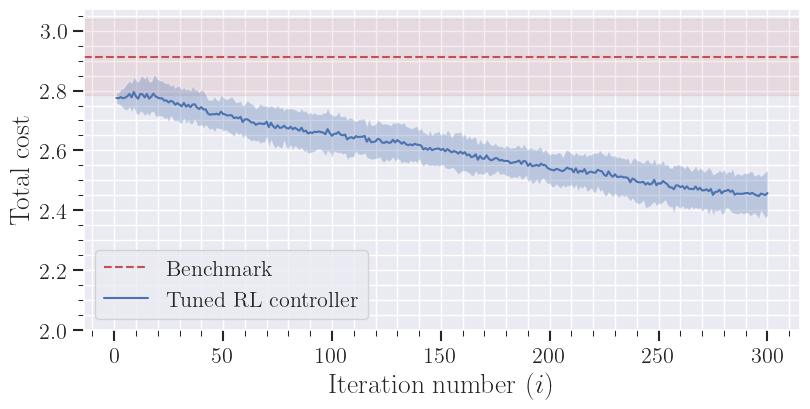

In [15]:
# sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "xtick.bottom" : True, 
    "ytick.left" : True,
    'xtick.major.size': 8,
    'xtick.major.width': 1.5,
    'xtick.minor.size': 4,
    'xtick.minor.width': 0.75,
    'ytick.major.size': 8,
    'ytick.major.width': 1.5,
    'ytick.minor.size': 4,
    'ytick.minor.width': 0.75,
})


def plot_total_cost(df, plot_type='means', savefig=False):
    if plot_type == 'means':
        central = df.mean(axis=1)
        stds = df.std(axis=1)
        bottom = central - stds
        top = central + stds
    elif plot_type == 'medians':
        central = df.median(axis=1)
        bottom = df.quantile(0.25, axis=1)
        top = df.quantile(0.75, axis=1)
    print(plot_type)
    
    fig, ax = plt.subplots(1, 1, figsize=(8,4))
    ax.set_ylabel("Total cost", fontsize=20)
    ax.set_xlabel("Iteration number $(i)$", fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.xaxis.grid(True, which='minor')
    ax.yaxis.grid(True, which='minor')
    
    plt.axhline(central_P, linestyle='--', color='r', label='Benchmark')
    plt.axhspan(bottom_P, top_P, alpha=0.1, color='r')
    
    central.plot(label='Tuned RL controller')
    plt.fill_between(central.index, bottom, top, alpha=0.3)
    
    plt.legend(fontsize=16)
    
    ax.set_ylim(bottom=2.0)  # Set bottom limit for y-axis to 2.0
    
    plt.tight_layout(pad=0.2)
    if savefig:
        plt.savefig("learning_curve_5_state.pdf", dpi=400)
    plt.show();

plot_total_cost(learning_curves, savefig=True)

Mean RL-cost for 5-state system

In [16]:
min(learning_curves.mean(axis=1))

2.4473602842883353

# Plot actions and observations

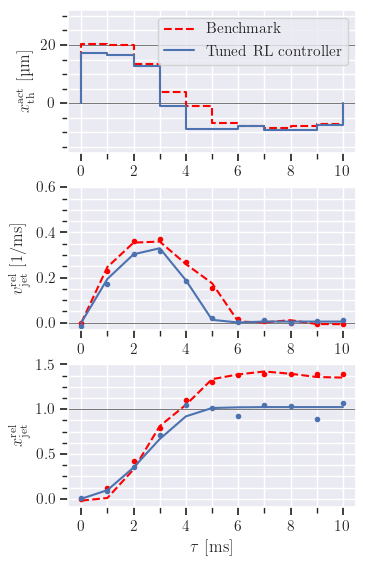

In [17]:
sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
})

seeds_colors = {
    '10': 'b',
    # '4': 'g',
    # '5': 'b',
    # '7': 'c',
    # '14': 'orange',
}

P_seeds_colors = {
    '10': 'r',
}

# def plot_iteration_results()
# LOAD IN ONE DATASET
iteration = 300

seed_observations = {}
seed_clean_observations = {}
seed_actions = {}

l_crit = system._parameters['l_crit'] # [mm]
step_size = simulator.step_size # [s]


P_clean_obs_df = pd.read_csv(
    pathes_P['2'] / "ground_truth_observations.csv", 
    index_col=0,
)
P_clean_obs_df /= l_crit
P_clean_obs_df['1'] *= step_size

P_obs_df = pd.read_csv(
    pathes_P['2'] / "observations.csv", 
    index_col=0,
)
P_obs_df /= l_crit
P_obs_df['1'] *= step_size

P_act_df = pd.read_csv(
    pathes_P['2'] / "actions.csv", 
    index_col=0,
)


for seed in seeds_colors:
    with open(pathes[seed] / "iteration_data.pkl", 'rb') as f:
        data = pickle.load(f)
    
    load_iteration = iteration
    if iteration > len(data):
        load_iteration = len(data)
    
    seed_clean_observations[seed] = data[load_iteration - 1]['ground_truth_observations']
    seed_observations[seed] = data[load_iteration - 1]['observations']
    seed_actions[seed] = [0.]
    seed_actions[seed].extend(data[load_iteration - 1]['actions'][:-1])
    
    seed_clean_observations[seed] /= l_crit
    seed_clean_observations[seed][:, 1] *= step_size
    seed_observations[seed] /= l_crit
    seed_observations[seed][:, 1] *= step_size

fig, axes = plt.subplots(3, 1, figsize=(4,6),) # gridspec_kw={'height_ratios': [0.8, 1, 1, 1]})
    
# PLOT ACTIONS
ax = axes[0]

ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)
ax.axhline(20, color='black', linewidth=0.5, alpha=0.75)

P_act_df.plot('step', 'action', color='red', linestyle='--', ax=ax, label='Benchmark')
i = 1
for seed in seeds_colors:
    real_actions = scenario.get_real_actions(seed_actions[seed])
    ax.plot(real_actions[:,0], real_actions[:,1], label='Tuned RL controller', color=seeds_colors[seed]) # f'our controller: seed {i}'
    i += 1
    

ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.xaxis.grid(True, which='minor')
ax.yaxis.grid(True, which='minor')

ax.set_ylim(top=32.0, bottom=-17.0)
    
ax.set_ylabel(r"$x^\mathrm{act}_\mathrm{th}$ [µm]")
ax.set_xlabel("")

ax.legend(loc='upper right')

# PLOT JET VELOCITIES
ax = axes[1]

ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)


P_obs_df.iloc[:,1].plot(color='red', linestyle='--', ax=ax)
P_clean_obs_df.iloc[:,1].plot(marker='.', color='red', linestyle='', ax=ax)

for seed in seeds_colors:
    ax.plot(seed_clean_observations[seed][:,1], color=seeds_colors[seed])
    ax.plot(seed_observations[seed][:,1], linestyle='', marker='.', color=seeds_colors[seed])
    
    
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.xaxis.grid(True, which='minor')
ax.yaxis.grid(True, which='minor')
    
ax.set_ylim(top=.6)
    
ax.set_ylabel(r"$v^\mathrm{rel}_\mathrm{jet}~[1/\mathrm{ms}]$")
ax.set_xlabel("")
    
    # ax.legend().set_visible(False)

# PLOT JET LENGTHS
ax = axes[2]

ax.axhline(1.0, color='black', linewidth=0.5, alpha=0.75)

P_obs_df.iloc[:,0].plot(color='red', linestyle='--', ax=ax)
P_clean_obs_df.iloc[:,0].plot(marker='.', color='red', linestyle='', ax=ax)

for seed in seeds_colors:
    ax.plot(seed_clean_observations[seed][:,0], label=seed, color=seeds_colors[seed])
    ax.plot(seed_observations[seed][:,0], linestyle='', marker='.', color=seeds_colors[seed])

# for iter, ax in zip(iterations_lt, axes[2,:].flat):
    
#     ax.axhline(0, color='black', linewidth=0.5, alpha=0.75)
    
#     sns.lineplot(df, x='time', y=f'jet_velocity_{iter}', color='purple', ax=ax)
    
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.125))
ax.xaxis.grid(True, which='minor')
ax.yaxis.grid(True, which='minor')

ax.set_ylim(top=1.5)
    
ax.set_ylabel(r"$x^\mathrm{rel}_\mathrm{jet}$")
ax.set_xlabel(r"$\tau$ [ms]")

plt.tight_layout(h_pad=0.1)
plt.savefig("simulation_results_5_state.pdf", dpi=400)

In [18]:
print(f'Achieved relative jet length: {seed_clean_observations[seed][:,0][-1]:.3f}')
print(f'Benchmark relative jet length: {P_clean_obs_df.iloc[-1, 0]:.3f}')

Achieved relative jet length: 1.023
Benchmark relative jet length: 1.397
